#Étude perception du temps vs musique
##Lucie GILLET & Luna MARIOTTE

In [2]:
### Import des bibliothèques nécessaires et lecture du fichier Excel
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf

# Chemin vers le fichier
excel_path = "test.xlsx"

# Lecture brute sans entête
raw = pd.read_excel(excel_path, header=None)

# Aperçu des premières lignes pour vérifier le format
raw.head(25)


,0,1,2
0,Musique 1,NaN,NaN
1,Participant,Différences,Appréciation
2,1,25,OUI
3,2,75,OUI
4,3,-15,OUI
5,4,45,OUI
6,5,31,OUI
7,6,15,OUI
8,7,5,OUI
9,8,5,OUI


In [3]:
# Fonction de parsing des blocs de musique
def parse_music_blocks(raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    Lit un fichier Excel structuré par blocs :
    - ligne 'Musique X'
    - ligne d'en-tête : Participant | Différences | Appréciation
    - lignes de données

    Retourne un DataFrame avec :
    musique | participant | difference | appreciation
    """
    df = raw_df.iloc[:, :3].copy()
    df.columns = ["c1", "c2", "c3"]

    current_music = None
    in_table = False
    rows = []

    for _, r in df.iterrows():
        c1, c2, c3 = r["c1"], r["c2"], r["c3"]

        # Début d'un bloc musique
        if isinstance(c1, str) and c1.strip().lower().startswith("musique"):
            current_music = c1.strip()
            in_table = False
            continue

        # Ligne d'en-tête
        if current_music is not None and isinstance(c1, str) and c1.strip().lower() == "participant":
            in_table = True
            continue

        # Lecture des lignes du tableau
        if in_table:
            # Fin du tableau
            if pd.isna(c1) and pd.isna(c2) and pd.isna(c3):
                in_table = False
                continue

            # Ignore les lignes incomplètes
            if pd.isna(c1) or pd.isna(c2) or pd.isna(c3):
                continue

            try:
                participant = int(c1)
            except:
                continue

            try:
                diff = float(c2)
            except:
                continue

            appreciation = str(c3).strip().upper()
            if appreciation in ["YES", "OUI"]:
                appreciation = "OUI"
            elif appreciation in ["NO", "NON"]:
                appreciation = "NON"
            else:
                continue

            rows.append({
                "musique": current_music,
                "participant": participant,
                "difference": diff,
                "appreciation": appreciation
            })

    out = pd.DataFrame(rows)

    if not out.empty:
        out = out.sort_values(["musique", "participant"]).reset_index(drop=True)

    return out


In [4]:
#Préparation des données

data = parse_music_blocks(raw)

print("Nb lignes :", len(data))
print("Musiques détectées :", data["musique"].unique())
print("Répartition appréciation :")
print(data["appreciation"].value_counts())

# Durées des musiques en secondes
# A modifier si besoin
durations = {
    "Musique 1": 75.0,
    "Musique 2": 35.0,
    "Musique 3": 80.0,
    "Musique 4": 90.0,
}

data["duration_s"] = data["musique"].map(durations)

missing = data["duration_s"].isna().sum()
if missing > 0:
    print(f"Attention : {missing} lignes sans durée associée.")
    print("Vérifie le dictionnaire 'durations'.")

data = data.dropna(subset=["duration_s"]).copy()

# Erreur normalisée
data["diff_norm"] = data["difference"] / data["duration_s"]

# Variable binaire pour les analyses
data["appreciation_bin"] = data["appreciation"].map({"NON": 0, "OUI": 1})



Nb lignes : 64
Musiques détectées : ['Musique 1' 'Musique 2' 'Musique 3' 'Musique 4']
Répartition appréciation :
appreciation
OUI    51
NON    13
Name: count, dtype: int64


In [5]:
#Descriptifs

summary_all = (
    data.groupby("appreciation")["diff_norm"]
    .agg(mean="mean", median="median", std="std", n="count")
    .reset_index()
)
summary_all["sem"] = summary_all["std"] / np.sqrt(summary_all["n"])

print("\n=== Résumé descriptif global ===")
print(summary_all)

summary_music = (
    data.groupby(["musique", "appreciation"])["diff_norm"]
    .agg(mean="mean", median="median", std="std", n="count")
    .reset_index()
)
summary_music["sem"] = summary_music["std"] / np.sqrt(summary_music["n"])

print("\n=== Résumé descriptif par musique ===")
print(summary_music)



=== Résumé descriptif global ===
  appreciation      mean  median       std   n       sem
0          NON  0.393864  0.3125  0.469227  13  0.130140
1          OUI  0.113040  0.0000  0.429673  51  0.060166

=== Résumé descriptif par musique ===
     musique appreciation      mean    median       std   n       sem
0  Musique 1          OUI  0.228333  0.200000  0.388970  16  0.097243
1  Musique 2          NON  0.209524  0.285714  0.461880   3  0.266667
2  Musique 2          OUI  0.059341  0.000000  0.512625  13  0.142176
3  Musique 3          NON  0.304167  0.281250  0.447679   6  0.182764
4  Musique 3          OUI  0.006250 -0.218750  0.529880  10  0.167563
5  Musique 4          NON  0.666667  0.611111  0.505118   4  0.252559
6  Musique 4          OUI  0.106481  0.000000  0.288635  12  0.083322


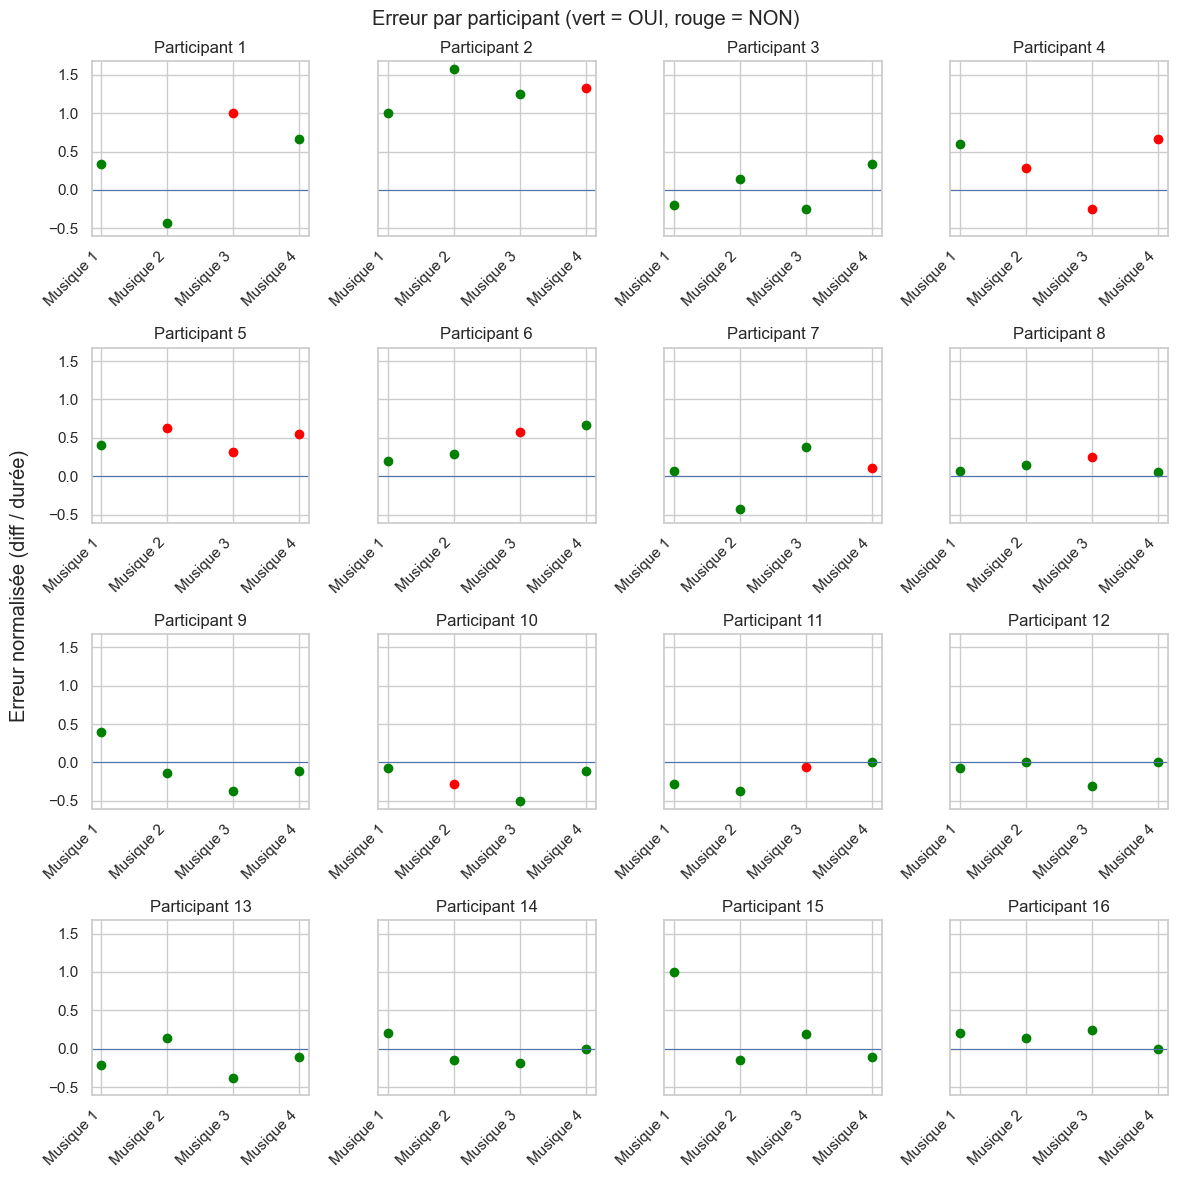

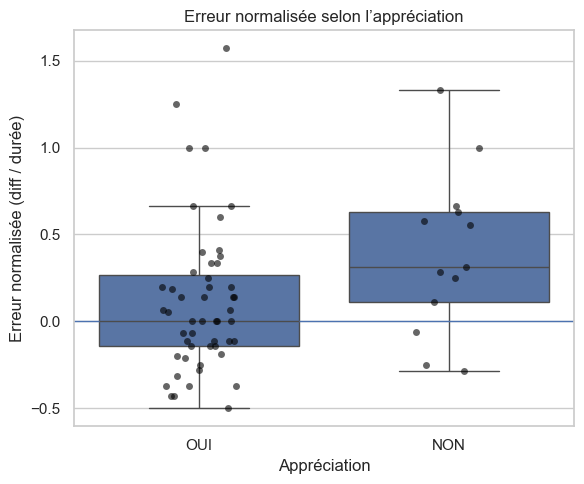

<Figure size 1000x500 with 0 Axes>

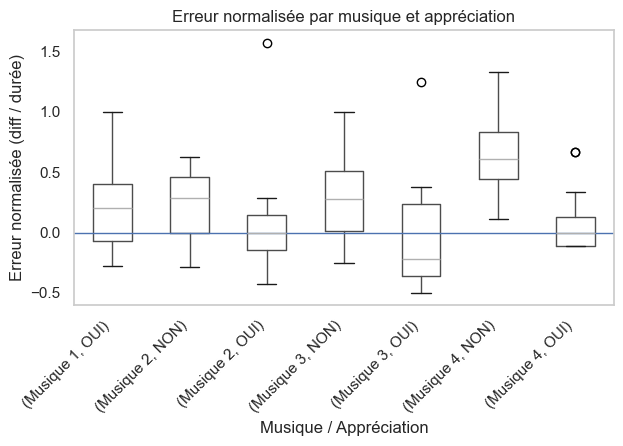

In [6]:
#Graphiques descriptifs

sns.set_theme(style="whitegrid")

# A. Erreur par participant
participants = sorted(data["participant"].unique())
n = len(participants)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3 * nrows), sharey=True)
axes = np.array(axes).flatten()

for ax, p in zip(axes, participants):
    df_p = data[data["participant"] == p]

    for i, (_, row) in enumerate(df_p.iterrows()):
        color = "green" if row["appreciation"] == "OUI" else "red"
        ax.scatter(i, row["diff_norm"], color=color)

    ax.axhline(0, linewidth=0.8)
    ax.set_title(f"Participant {p}")
    ax.set_xticks(range(len(df_p)))
    ax.set_xticklabels(df_p["musique"], rotation=45, ha="right")

for ax in axes[n:]:
    ax.set_visible(False)

fig.supylabel("Erreur normalisée (diff / durée)")
fig.suptitle("Erreur par participant (vert = OUI, rouge = NON)")
plt.tight_layout()
plt.show()

# B. Boxplot global
plt.figure(figsize=(6, 5))
sns.boxplot(data=data, x="appreciation", y="diff_norm", showfliers=False)
sns.stripplot(data=data, x="appreciation", y="diff_norm", color="black", alpha=0.6, jitter=0.15)
plt.axhline(0, linewidth=1)
plt.xlabel("Appréciation")
plt.ylabel("Erreur normalisée (diff / durée)")
plt.title("Erreur normalisée selon l’appréciation")
plt.tight_layout()
plt.show()

# C. Par musique et appréciation
plt.figure(figsize=(10, 5))
data.boxplot(column="diff_norm", by=["musique", "appreciation"], grid=False)
plt.axhline(0, linewidth=1)
plt.ylabel("Erreur normalisée (diff / durée)")
plt.xlabel("Musique / Appréciation")
plt.title("Erreur normalisée par musique et appréciation")
plt.suptitle("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


=== Analyse intra-sujets ===
Nombre de participants avec OUI et NON : 9
Moyenne des différences appariées (OUI - NON) = -0.1270
Shapiro-Wilk sur (OUI - NON) : W = 0.846, p = 0.0676

Test principal choisi : t-test apparié
t = -1.239, p = 0.2505

=== Interprétation test principal ===
Le t-test apparié ne met pas en évidence de différence significative entre OUI et NON.


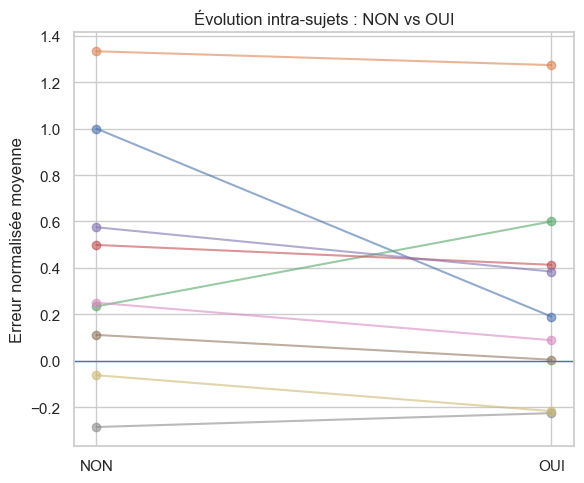

In [9]:
#Analyse intra-sujets

alpha = 0.05

paired = (
    data.groupby(["participant", "appreciation_bin"])["diff_norm"]
    .mean()
    .unstack()
)

paired = paired.dropna(subset=[0, 1]).copy()
paired.columns = ["NON", "OUI"]

print("\n=== Analyse intra-sujets ===")
print(f"Nombre de participants avec OUI et NON : {len(paired)}")

if len(paired) < 3:
    print("Pas assez de participants pour faire un test apparié fiable.")
else:
    diff = paired["OUI"] - paired["NON"]
    print(f"Moyenne des différences appariées (OUI - NON) = {diff.mean():.4f}")

    # Test de normalité
    shapiro_res = stats.shapiro(diff)
    print(f"Shapiro-Wilk sur (OUI - NON) : W = {shapiro_res.statistic:.3f}, p = {shapiro_res.pvalue:.4f}")

    # Choix du test
    if shapiro_res.pvalue > alpha:
        primary_test = stats.ttest_rel(paired["OUI"], paired["NON"])
        test_name = "t-test apparié"
        print("\nTest principal choisi : t-test apparié")
        print(f"t = {primary_test.statistic:.3f}, p = {primary_test.pvalue:.4f}")
    else:
        if np.allclose(diff.values, 0):
            primary_test = None
            test_name = "Wilcoxon apparié"
            print("\nToutes les différences sont nulles : Wilcoxon non informatif.")
        else:
            primary_test = stats.wilcoxon(paired["OUI"], paired["NON"], zero_method="wilcox")
            test_name = "Wilcoxon apparié"
            print("\nTest principal choisi : Wilcoxon apparié")
            print(f"W = {primary_test.statistic:.3f}, p = {primary_test.pvalue:.4f}")

    # Interprétation
    print("\n=== Interprétation test principal ===")
    if primary_test is not None:
        if primary_test.pvalue < alpha:
            print(f"Le {test_name} met en évidence une différence significative entre OUI et NON.")
        else:
            print(f"Le {test_name} ne met pas en évidence de différence significative entre OUI et NON.")

    # Graphique intra-sujets
    plt.figure(figsize=(6, 5))
    for idx in paired.index:
        plt.plot(["NON", "OUI"], [paired.loc[idx, "NON"], paired.loc[idx, "OUI"]], marker="o", alpha=0.6)
    plt.axhline(0, linewidth=1)
    plt.ylabel("Erreur normalisée moyenne")
    plt.title("Évolution intra-sujets : NON vs OUI")
    plt.tight_layout()
    plt.show()


In [8]:
#Régression

reg_df = data.dropna(subset=["diff_norm", "appreciation_bin", "participant", "musique"]).copy()

model = smf.ols(
    "diff_norm ~ appreciation_bin + C(participant) + C(musique)",
    data=reg_df
).fit(cov_type="HC3")

coef = model.params["appreciation_bin"]
pval = model.pvalues["appreciation_bin"]
ci_low, ci_high = model.conf_int().loc["appreciation_bin"]

print("\n=== Régression linéaire ===")
print(f"Coefficient appreciation_bin = {coef:.4f}")
print(f"p-value = {pval:.4f}")
print(f"IC95% = [{ci_low:.4f} ; {ci_high:.4f}]")

print("\n=== Interprétation régression ===")
if pval < alpha:
    print("La régression met en évidence un effet significatif de l’appréciation sur l’erreur normalisée.")
else:
    print("La régression ne met pas en évidence d’effet significatif de l’appréciation sur l’erreur normalisée.")


=== Régression linéaire ===
Coefficient appreciation_bin = -0.1993
p-value = 0.1890
IC95% = [-0.4967 ; 0.0981]

=== Interprétation régression ===
La régression ne met pas en évidence d’effet significatif de l’appréciation sur l’erreur normalisée.


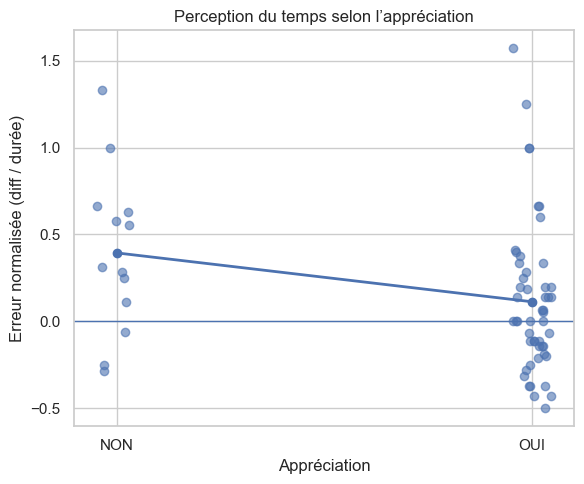

In [ ]:
#Graphique final

fig, ax = plt.subplots(figsize=(6, 5))

rng = np.random.default_rng(42)
x_jitter = reg_df["appreciation_bin"] + rng.uniform(-0.05, 0.05, size=len(reg_df))

# points
ax.scatter(x_jitter, reg_df["diff_norm"], alpha=0.6)

# moyenne par groupe
means = reg_df.groupby("appreciation_bin")["diff_norm"].mean()
ax.plot([0, 1], [means.loc[0], means.loc[1]], marker="o", linewidth=2)

ax.axhline(0, linewidth=1)
ax.set_xticks([0, 1])
ax.set_xticklabels(["NON", "OUI"])
ax.set_xlabel("Appréciation")
ax.set_ylabel("Erreur normalisée (diff / durée)")
ax.set_title("Perception du temps selon l’appréciation")

fig.tight_layout()
fig.savefig("regression_appreciation.png", dpi=300, bbox_inches="tight")
plt.show()